In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.datasets import CIFAR10

In [2]:
from torch.utils.data import DataLoader
from torchvision.transforms import transforms
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(), # Flips image 50% of the time
    transforms.RandomRotation(10),
    transforms.ToTensor(), # scales(0,1) and tensor
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize(-1,1)
])

In [4]:
train_set = CIFAR10(root='./data', train=True, download=False, transform=transform)
test_set = CIFAR10(root='./data', train=False, download=False, transform=transform)

In [5]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64)

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # Stacked conv + Pooling layers
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(4*4*128, 256),
            nn.ReLU(),

            nn.Linear(256, 10)
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

In [7]:
model = CNN()

criterion = nn.CrossEntropyLoss()
optimiser = optim.Adam(model.parameters())

In [8]:
epochs = 10
train_loss = []
val_loss = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        optimiser.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimiser.step()

        running_loss += loss.item()
    epoch_train_loss = running_loss / len(train_loader)
    train_loss.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
    epoch_val_loss = running_val_loss / len(test_loader)
    val_loss.append(epoch_val_loss)
            
    print(f'epoch {epoch+1}/{epochs} train loss : {epoch_train_loss} and val loss: {epoch_val_loss}')

epoch 1/10 train loss : 1.2357948201391704 and val loss: 1.0203983377499186
epoch 2/10 train loss : 0.9130945772771031 and val loss: 0.9402471917450048
epoch 3/10 train loss : 0.7899742221740811 and val loss: 0.8044870023135167
epoch 4/10 train loss : 0.714758700231457 and val loss: 0.7508508644665882
epoch 5/10 train loss : 0.6614540351168884 and val loss: 0.7259459823939451
epoch 6/10 train loss : 0.6195765452083114 and val loss: 0.6639751044048625
epoch 7/10 train loss : 0.5823535849447445 and val loss: 0.6887666560282373
epoch 8/10 train loss : 0.5468304434891247 and val loss: 0.6661361793803561
epoch 9/10 train loss : 0.5178326593564294 and val loss: 0.6242175278769937
epoch 10/10 train loss : 0.4959873088904659 and val loss: 0.6091177579323956


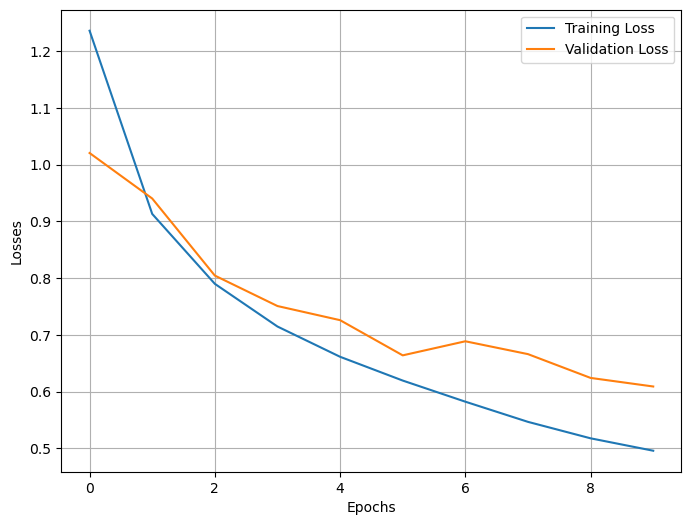

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

new_df = pd.DataFrame({
    'training_loss': train_loss,
    'val_loss': val_loss
})

plt.figure(figsize=(8,6))
plt.plot(new_df['training_loss'], label='Training Loss')
plt.plot(new_df['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Losses')
plt.legend()
plt.grid()

In [10]:
correct_labels = 0
total_labels = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f'Accuracy: {correct_labels / total_labels * 100}')

Accuracy: 78.75
